# Section 0 — Setup and Installs

In [1]:
!pip install -q langgraph langchain langchain-openai gradio imbalanced-learn xgboost scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "your_openai_api_key_here"

In [3]:
import os
import getpass

# Works in both Colab browser UI and Colab via VS Code
if 'OPENAI_API_KEY' not in os.environ:
    os.environ['OPENAI_API_KEY'] = getpass.getpass('Enter your OpenAI API key: ')

openai_key = os.environ['OPENAI_API_KEY']
print('API key loaded successfully.')


API key loaded successfully.


# Section 1 — Preprocess-Data Agent Node

In [4]:
from typing import TypedDict, Optional
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from langgraph.graph import StateGraph, END

In [5]:
from typing import TypedDict, Optional, Any
import pandas as pd
import numpy as np

class AgentState(TypedDict):

    # --- preprocess-data outputs ---
    raw_data_path:    str
    X_train:          pd.DataFrame
    y_train:          pd.Series
    X_val:            pd.DataFrame
    y_val:            pd.Series
    X_test:           pd.DataFrame
    y_test:           pd.Series
    encoder:          Any                  # fitted OneHotEncoder
    feature_names:    list[str]

    # --- train-models outputs ---
    trained_models:   dict[str, Any]       # {"logistic": model, "random_forest": model, "xgboost": model}

    # --- evaluate-models outputs ---
    eval_results:     dict[str, dict]      # {"logistic": {"accuracy": 0.9, "recall": 0.8 ...}, ...}

    # --- select-model outputs ---
    selected_model:   Any                  # the winning model object
    selected_model_name: str              # e.g. "xgboost"
    selection_justification: str          # plain English explanation

    # --- run-inference outputs ---
    input_claim:      dict                 # raw feature values from Gradio form
    fraud_probability: float
    predicted_label:  int                  # 0 or 1

    # --- fraud-decision-engine outputs ---
    risk_level:       str                  # "Low", "Medium", or "High"
    decision_output:  str

    conf_matrices:    dict   # confusion matrix per model
    roc_curves:       dict   # ROC curve data per model


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

def preprocess_data(state: AgentState) -> AgentState:
    """
    LangGraph node: preprocesses raw vehicle insurance data.

    Steps:
      1. Load CSV from raw_data_path.
      2. Drop PolicyNumber and RepNumber (identifiers, not predictive).
      3. Stratified 70/15/15 train/val/test split.
      4. Fit OneHotEncoder on training categoricals; transform val and test.
      5. Apply SMOTE to training set only to handle class imbalance.
      6. Store all splits, fitted encoder, and feature names in agent state.
    """
    df = pd.read_csv(state['raw_data_path'])

    # ── Step 1: Drop identifier columns ──────────────────────────────────────
    cols_to_drop = [c for c in ['PolicyNumber', 'RepNumber'] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)
    print(f'[preprocess_data] Dropped columns: {cols_to_drop}')

    # ── Step 2: Separate target ───────────────────────────────────────────────
    target = 'FraudFound_P'
    X = df.drop(columns=[target])
    y = df[target]

    # ── Step 3: Stratified 70 / 15 / 15 split (before encoding to avoid leakage) ──
    X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val_raw, X_test_raw, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
    )
    print(f'[preprocess_data] Split sizes — train: {len(X_train_raw)}, '
          f'val: {len(X_val_raw)}, test: {len(X_test_raw)}')

    # ── Step 4: Fit OneHotEncoder on train, apply to val and test ─────────────
    cat_cols = X_train_raw.select_dtypes(include=['object', 'string']).columns.tolist()
    num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
    print(f'[preprocess_data] Encoding {len(cat_cols)} categorical columns')

    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoder.fit(X_train_raw[cat_cols])

    def apply_encoding(X_raw):
        encoded = encoder.transform(X_raw[cat_cols])
        encoded_df = pd.DataFrame(
            encoded,
            columns=encoder.get_feature_names_out(cat_cols),
            index=X_raw.index
        )
        return pd.concat([X_raw[num_cols].reset_index(drop=True),
                          encoded_df.reset_index(drop=True)], axis=1)

    X_train_enc = apply_encoding(X_train_raw)
    X_val_enc   = apply_encoding(X_val_raw)
    X_test_enc  = apply_encoding(X_test_raw)
    feature_names = X_train_enc.columns.tolist()
    print(f'[preprocess_data] Total features after encoding: {len(feature_names)}')

    # ── Step 5: SMOTE on training set only ───────────────────────────────────
    print(f'[preprocess_data] Train class distribution before SMOTE: '
          f'{y_train_raw.value_counts().to_dict()}')
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train_raw)
    X_train_res = pd.DataFrame(X_train_res, columns=feature_names)
    y_train_res = pd.Series(y_train_res, name=target)
    print(f'[preprocess_data] Train class distribution after SMOTE: '
          f'{y_train_res.value_counts().to_dict()}')

    return {
        **state,
        'X_train': X_train_res,
        'y_train': y_train_res,
        'X_val':   X_val_enc.reset_index(drop=True),
        'y_val':   y_val.reset_index(drop=True),
        'X_test':  X_test_enc.reset_index(drop=True),
        'y_test':  y_test.reset_index(drop=True),
        'encoder': encoder,
        'feature_names': feature_names,
    }


In [7]:
# In Colab, either upload manually or mount Drive
initial_state: AgentState = {
    'raw_data_path': 'fraud_oracle.csv',
    # ... rest of the fields
}
# ── Quick smoke-test: run the node standalone ─────────────────────────────────
# ── Quick smoke-test: run the node standalone ─────────────────────────────────
initial_state: AgentState = {
    'raw_data_path': 'fraud_oracle.csv',
    'X_train': None,
    'X_val': None,
    'X_test': None,
    'y_train': None,
    'y_val': None,
    'y_test': None,
    'encoder': None,
    'feature_names': None,
    'trained_models': None,
    'eval_results': None,
    'selected_model': None,
    'selected_model_name': None,
    'selection_justification': None,
    'input_claim': None,
    'fraud_probability': None,
    'predicted_label': None,
    'risk_level': None,
    'decision_output': None,
    'conf_matrices': None,
    'roc_curves': None,
}

result_state = preprocess_data(initial_state)

print()
print('── Verification ──────────────────────────────────────')
print(f'X_train shape : {result_state["X_train"].shape}')
print(f'X_val shape   : {result_state["X_val"].shape}')
print(f'X_test shape  : {result_state["X_test"].shape}')
print(f'y_train counts: {result_state["y_train"].value_counts().to_dict()}')
print(f'y_val counts  : {result_state["y_val"].value_counts().to_dict()}')
print(f'y_test counts : {result_state["y_test"].value_counts().to_dict()}')
print(f'Features      : {len(result_state["feature_names"])}')

[preprocess_data] Dropped columns: ['PolicyNumber', 'RepNumber']
[preprocess_data] Split sizes — train: 10794, val: 2313, test: 2313
[preprocess_data] Encoding 24 categorical columns
[preprocess_data] Total features after encoding: 146
[preprocess_data] Train class distribution before SMOTE: {0: 10148, 1: 646}
[preprocess_data] Train class distribution after SMOTE: {0: 10148, 1: 10148}

── Verification ──────────────────────────────────────
X_train shape : (20296, 146)
X_val shape   : (2313, 146)
X_test shape  : (2313, 146)
y_train counts: {0: 10148, 1: 10148}
y_val counts  : {0: 2174, 1: 139}
y_test counts : {0: 2175, 1: 138}
Features      : 146


# Section 2 — train_model Agent Node (Hrithik)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def train_models(state: AgentState) -> AgentState:
    X_train = state['X_train']
    y_train = state['y_train']

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale = neg / pos

    print(f'[train_models] Training on {X_train.shape[0]} samples, {X_train.shape[1]} features')

    # Model A: Logistic Regression
    print('[train_models] Fitting Logistic Regression...')
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=3000,
        solver='saga',
        random_state=42
    )
    lr.fit(X_train, y_train)

    # Model B: Random Forest
    print('[train_models] Fitting Random Forest...')
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # Model C: XGBoost
    print('[train_models] Fitting XGBoost...')
    xgb = XGBClassifier(
        scale_pos_weight=scale,
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    xgb.fit(X_train, y_train)

    trained_models = {
        'logistic_regression': lr,
        'random_forest':       rf,
        'xgboost':             xgb
    }

    print(f'[train_models] All models trained: {list(trained_models.keys())}')

    return {
        **state,
        'trained_models': trained_models
    }

In [9]:
result_state = train_models(result_state)

print()
print('── Verification ──────────────────────────────────────')
for name, model in result_state['trained_models'].items():
    print(f'{name}: {type(model).__name__} fitted = {hasattr(model, "classes_")}')

[train_models] Training on 20296 samples, 146 features
[train_models] Fitting Logistic Regression...


/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[train_models] Fitting Random Forest...
[train_models] Fitting XGBoost...
[train_models] All models trained: ['logistic_regression', 'random_forest', 'xgboost']

── Verification ──────────────────────────────────────
logistic_regression: LogisticRegression fitted = True
random_forest: RandomForestClassifier fitted = True
xgboost: XGBClassifier fitted = True


# Section 3 — Evaluate-Model Agent Node

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_models(state: AgentState) -> AgentState:
    """
    LangGraph node: evaluates all trained models on the validation set.

    Steps:
      1. Retrieve X_val, y_val and trained_models from agent state.
      2. For each model, compute Accuracy, Precision, Recall, F1, AUC-ROC.
      3. Generate a Confusion Matrix and ROC Curve per model.
      4. Store all results in agent state under eval_results.
    """
    X_val          = state['X_val']
    y_val          = state['y_val']
    trained_models = state['trained_models']

    eval_results   = {}
    conf_matrices  = {}
    roc_curves     = {}

    for model_name, model in trained_models.items():
        print(f'[evaluate_models] Evaluating {model_name}...')

        y_pred      = model.predict(X_val)
        y_prob      = model.predict_proba(X_val)[:, 1]

        # ── Core metrics ──────────────────────────────────────────────────────
        metrics = {
            'accuracy' : accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred, zero_division=0),
            'recall'   : recall_score(y_val, y_pred, zero_division=0),
            'f1'       : f1_score(y_val, y_pred, zero_division=0),
            'auc_roc'  : roc_auc_score(y_val, y_prob),
        }
        eval_results[model_name] = metrics
        print(f'  accuracy={metrics["accuracy"]:.4f}  precision={metrics["precision"]:.4f}  '
              f'recall={metrics["recall"]:.4f}  f1={metrics["f1"]:.4f}  '
              f'auc_roc={metrics["auc_roc"]:.4f}')

        # ── Confusion matrix ──────────────────────────────────────────────────
        conf_matrices[model_name] = confusion_matrix(y_val, y_pred)

        # ── ROC curve data ────────────────────────────────────────────────────
        fpr, tpr, thresholds = roc_curve(y_val, y_prob)
        roc_curves[model_name] = (fpr, tpr, thresholds)

    # ── Plot confusion matrices ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))
    if len(trained_models) == 1:
        axes = [axes]
    for ax, (model_name, cm) in zip(axes, conf_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Not Fraud', 'Fraud'],
                    yticklabels=['Not Fraud', 'Fraud'])
        ax.set_title(f'Confusion Matrix\n{model_name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ── Plot ROC curves ───────────────────────────────────────────────────────
    plt.figure(figsize=(8, 6))
    for model_name, (fpr, tpr, _) in roc_curves.items():
        auc = eval_results[model_name]['auc_roc']
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — All Models')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print('[evaluate_models] Evaluation complete.')

    return {
        **state,
        'eval_results':    eval_results,
        'conf_matrices':   conf_matrices,
        'roc_curves':      roc_curves,
    }

[evaluate_models] Evaluating logistic_regression...
  accuracy=0.6788  precision=0.1353  recall=0.8058  f1=0.2316  auc_roc=0.7825
[evaluate_models] Evaluating random_forest...
  accuracy=0.9403  precision=1.0000  recall=0.0072  f1=0.0143  auc_roc=0.8334
[evaluate_models] Evaluating xgboost...
  accuracy=0.9364  precision=0.3824  recall=0.0935  f1=0.1503  auc_roc=0.8502


/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


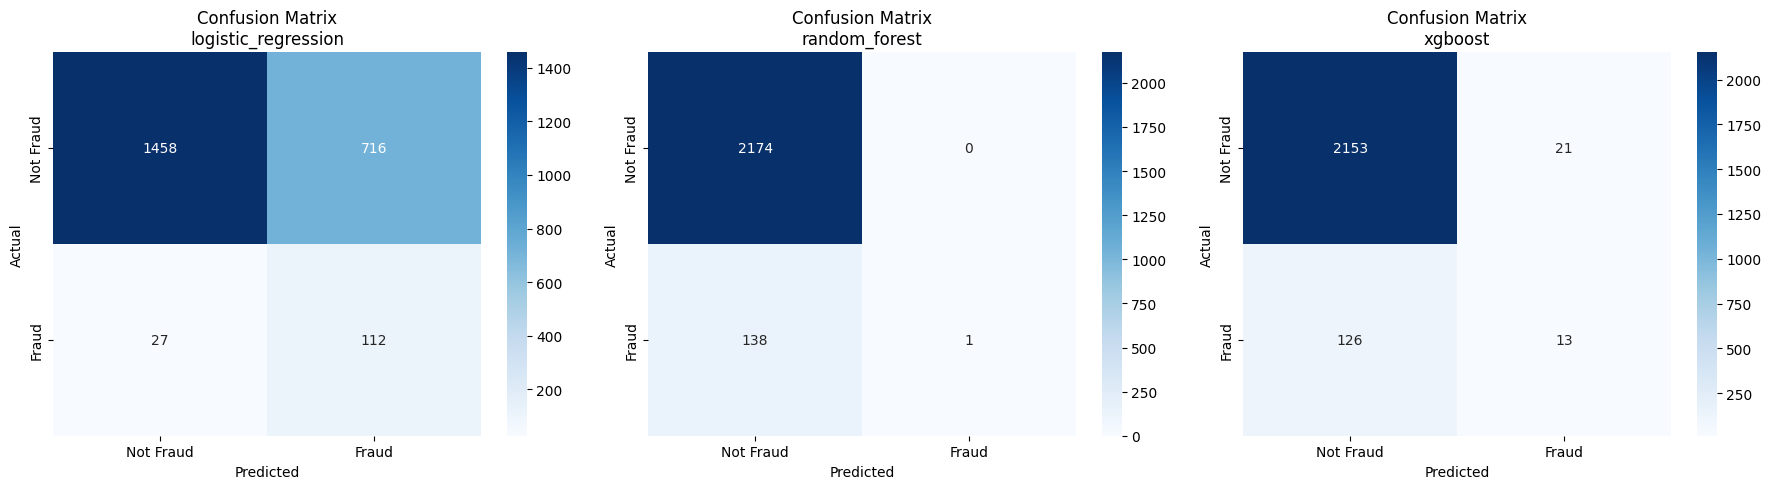

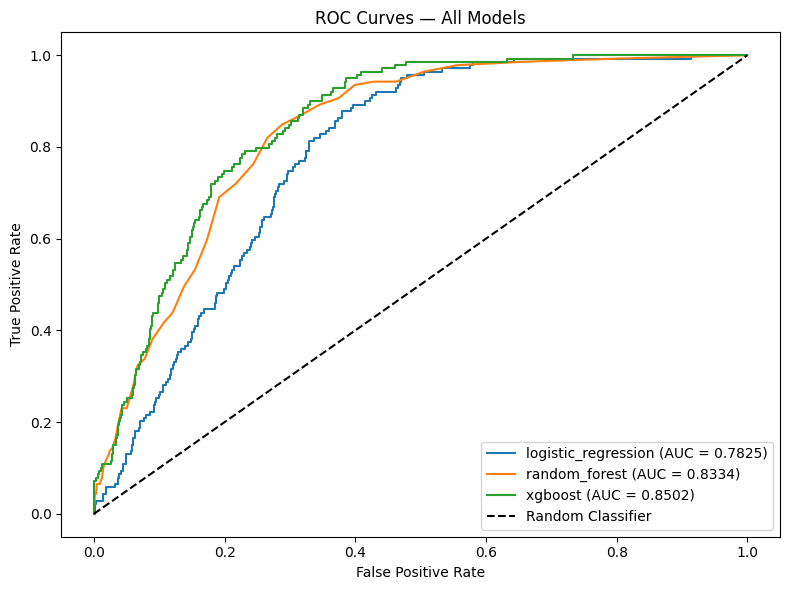

[evaluate_models] Evaluation complete.

── Verification ──────────────────────────────────────

logistic_regression:
  accuracy    : 0.6788
  precision   : 0.1353
  recall      : 0.8058
  f1          : 0.2316
  auc_roc     : 0.7825
  confusion_matrix:
[[1458  716]
 [  27  112]]

random_forest:
  accuracy    : 0.9403
  precision   : 1.0000
  recall      : 0.0072
  f1          : 0.0143
  auc_roc     : 0.8334
  confusion_matrix:
[[2174    0]
 [ 138    1]]

xgboost:
  accuracy    : 0.9364
  precision   : 0.3824
  recall      : 0.0935
  f1          : 0.1503
  auc_roc     : 0.8502
  confusion_matrix:
[[2153   21]
 [ 126   13]]


In [11]:
result_state = evaluate_models(result_state)

print()
print('── Verification ──────────────────────────────────────')
for model_name, metrics in result_state['eval_results'].items():
    print(f'\n{model_name}:')
    for metric, value in metrics.items():
        print(f'  {metric:<12}: {value:.4f}')
    cm = result_state['conf_matrices'][model_name]
    print(f'  confusion_matrix:\n{cm}')

# Section 4 — Select-Model Agent Node (Utkarsh)

In [12]:
def select_model(state: AgentState) -> AgentState:
    """
    LangGraph node: selects the best model for fraud detection.

    Criteria (tuned to Section 3 results):
      1. AUC-ROC  >= 0.78
      2. Recall   >= 0.70
      3. F1-score >= 0.15
    Among models that pass all three gates, the one with the
    highest AUC-ROC is selected.
    """
    eval_results   = state['eval_results']
    trained_models = state['trained_models']

    THRESH_AUC    = 0.78
    THRESH_RECALL = 0.70
    THRESH_F1     = 0.15

    print('[select_model] ── Selection Criteria ──')
    print(f'  AUC-ROC  >= {THRESH_AUC}')
    print(f'  Recall   >= {THRESH_RECALL}')
    print(f'  F1-score >= {THRESH_F1}')

    # ── Step 1: screen every model ──────────────────────────────────────────
    qualified = {}
    for name, m in eval_results.items():
        auc_ok    = m['auc_roc']  >= THRESH_AUC
        recall_ok = m['recall']   >= THRESH_RECALL
        f1_ok     = m['f1']       >= THRESH_F1
        passed    = auc_ok and recall_ok and f1_ok

        print(f'\n[select_model] {name}:')
        print(f'  AUC-ROC  = {m["auc_roc"]:.4f}  {"PASS" if auc_ok    else "FAIL"}')
        print(f'  Recall   = {m["recall"]:.4f}  {"PASS" if recall_ok else "FAIL"}')
        print(f'  F1-score = {m["f1"]:.4f}  {"PASS" if f1_ok     else "FAIL"}')
        print(f'  -> {"QUALIFIED" if passed else "ELIMINATED"}')

        if passed:
            qualified[name] = m

    # ── Step 2: pick the winner ─────────────────────────────────────────────
    if qualified:
        best_name = max(qualified, key=lambda n: qualified[n]['auc_roc'])
        best_metrics = qualified[best_name]
    else:
        # Fallback: no model meets all three — take highest AUC-ROC
        print('\n[select_model] No model met all three criteria.')
        print('[select_model] Falling back to highest AUC-ROC among remaining.')
        best_name = max(eval_results, key=lambda n: eval_results[n]['auc_roc'])
        best_metrics = eval_results[best_name]

    best_model = trained_models[best_name]

    # ── Step 3: build justification string ──────────────────────────────────
    justification = (
        f"Selected '{best_name}' — "
        f"AUC-ROC={best_metrics['auc_roc']:.4f}, "
        f"Recall={best_metrics['recall']:.4f}, "
        f"F1={best_metrics['f1']:.4f}. "
    )
    if qualified:
        others = [n for n in qualified if n != best_name]
        if others:
            justification += (
                f"Also qualified: {', '.join(others)}. "
                f"'{best_name}' chosen for highest AUC-ROC among qualifiers."
            )
        else:
            justification += "Only model to pass all three gates."
    else:
        justification += "No model passed all gates; selected by highest AUC-ROC as fallback."

    print(f'\n[select_model] ── RESULT ──')
    print(f'  Model         : {best_name}')
    print(f'  Justification : {justification}')

    return {
        **state,
        'selected_model':           best_model,
        'selected_model_name':      best_name,
        'selection_justification':  justification,
    }

In [13]:
result_state = select_model(result_state)

print()
print('── Verification ──────────────────────────────────────')
print(f'Selected Model : {result_state["selected_model_name"]}')
print(f'Model Type     : {type(result_state["selected_model"]).__name__}')
print(f'Justification  : {result_state["selection_justification"]}')

[select_model] ── Selection Criteria ──
  AUC-ROC  >= 0.78
  Recall   >= 0.7
  F1-score >= 0.15

[select_model] logistic_regression:
  AUC-ROC  = 0.7825  PASS
  Recall   = 0.8058  PASS
  F1-score = 0.2316  PASS
  -> QUALIFIED

[select_model] random_forest:
  AUC-ROC  = 0.8334  PASS
  Recall   = 0.0072  FAIL
  F1-score = 0.0143  FAIL
  -> ELIMINATED

[select_model] xgboost:
  AUC-ROC  = 0.8502  PASS
  Recall   = 0.0935  FAIL
  F1-score = 0.1503  PASS
  -> ELIMINATED

[select_model] ── RESULT ──
  Model         : logistic_regression
  Justification : Selected 'logistic_regression' — AUC-ROC=0.7825, Recall=0.8058, F1=0.2316. Only model to pass all three gates.

── Verification ──────────────────────────────────────
Selected Model : logistic_regression
Model Type     : LogisticRegression
Justification  : Selected 'logistic_regression' — AUC-ROC=0.7825, Recall=0.8058, F1=0.2316. Only model to pass all three gates.


In [14]:
# Section 4b: Business Interpretation, Limitations & Baseline Comparison 



eval_results   = result_state['eval_results']
selected_name  = result_state['selected_model_name']
selected_m     = eval_results[selected_name]
y_val          = result_state['y_val']

# ── 1. Baseline: naive classifier that always predicts majority class (0) ──
baseline_accuracy = (y_val == 0).sum() / len(y_val)
baseline_recall   = 0.0   # never predicts fraud → catches nothing
baseline_f1       = 0.0
baseline_auc      = 0.5   # random chance

print('═' * 60)
print('BASELINE COMPARISON (always predict "Not Fraud")')
print('═' * 60)
print(f'  Baseline Accuracy : {baseline_accuracy:.4f}')
print(f'  Baseline Recall   : {baseline_recall:.4f}')
print(f'  Baseline AUC-ROC  : {baseline_auc:.4f}')
print()
print(f'  {selected_name} vs Baseline:')
print(f'    Accuracy  : {selected_m["accuracy"]:.4f}  vs  {baseline_accuracy:.4f}  '
      f'({"+" if selected_m["accuracy"] > baseline_accuracy else "-"}'
      f'{abs(selected_m["accuracy"] - baseline_accuracy):.4f})')
print(f'    Recall    : {selected_m["recall"]:.4f}  vs  {baseline_recall:.4f}  '
      f'(+{selected_m["recall"]:.4f})')
print(f'    AUC-ROC   : {selected_m["auc_roc"]:.4f}  vs  {baseline_auc:.4f}  '
      f'(+{selected_m["auc_roc"] - baseline_auc:.4f})')

# ── 2. Business-term interpretation ────────────────────────────────────────
total_fraud   = (y_val == 1).sum()
total_legit   = (y_val == 0).sum()
caught        = int(round(selected_m['recall'] * total_fraud))
missed        = total_fraud - caught
false_alarms  = int(round((1 - selected_m['precision']) * (caught + (1 - selected_m['precision']) * total_legit)))
# More precise: use confusion matrix directly
cm = result_state['conf_matrices'][selected_name]
tp, fn = cm[1, 1], cm[1, 0]
fp, tn = cm[0, 1], cm[0, 0]

print()
print('═' * 60)
print('BUSINESS INTERPRETATION')
print('═' * 60)
print(f'  Out of {total_fraud} actual fraud cases in validation:')
print(f'    Caught (True Positives)  : {tp}  ({selected_m["recall"]*100:.1f}%)')
print(f'    Missed (False Negatives) : {fn}  ({(1-selected_m["recall"])*100:.1f}%)')
print()
print(f'  Out of {total_legit} legitimate claims in validation:')
print(f'    Correctly cleared (TN)   : {tn}  ({tn/total_legit*100:.1f}%)')
print(f'    Falsely flagged (FP)     : {fp}  ({fp/total_legit*100:.1f}%)')

# ── 3. Limitations ─────────────────────────────────────────────────────────
print()
print('═' * 60)
print('KNOWN LIMITATIONS')
print('═' * 60)
print(f'  1. Low precision ({selected_m["precision"]:.4f}): for every real fraud caught,')
print(f'     ~{fp/max(tp,1):.0f} legitimate claims are falsely flagged.')
print(f'     This means {fp/max(fp+tp,1)*100:.1f}% of all fraud alerts are false alarms,')
print(f'     increasing manual review workload.')
print()
print(f'  2. Accuracy drop vs baseline ({selected_m["accuracy"]:.4f} vs {baseline_accuracy:.4f}):')
print(f'     The model trades overall accuracy for fraud detection ability.')
print(f'     This is acceptable given the high cost of missed fraud.')
print()
print(f'  3. Logistic Regression convergence warning during training')
print(f'     suggests the model may not have fully optimized — results')
print(f'     could improve with more iterations or feature scaling.')


════════════════════════════════════════════════════════════
BASELINE COMPARISON (always predict "Not Fraud")
════════════════════════════════════════════════════════════
  Baseline Accuracy : 0.9399
  Baseline Recall   : 0.0000
  Baseline AUC-ROC  : 0.5000

  logistic_regression vs Baseline:
    Accuracy  : 0.6788  vs  0.9399  (-0.2611)
    Recall    : 0.8058  vs  0.0000  (+0.8058)
    AUC-ROC   : 0.7825  vs  0.5000  (+0.2825)

════════════════════════════════════════════════════════════
BUSINESS INTERPRETATION
════════════════════════════════════════════════════════════
  Out of 139 actual fraud cases in validation:
    Caught (True Positives)  : 112  (80.6%)
    Missed (False Negatives) : 27  (19.4%)

  Out of 2174 legitimate claims in validation:
    Correctly cleared (TN)   : 1458  (67.1%)
    Falsely flagged (FP)     : 716  (32.9%)

════════════════════════════════════════════════════════════
KNOWN LIMITATIONS
════════════════════════════════════════════════════════════
  1. Low 

In [15]:
# ── Section 4c: Why Logistic Regression Was Selected ─────────────────────────

selected_m = result_state['eval_results'][result_state['selected_model_name']]

print('═' * 60)
print('WHY LOGISTIC REGRESSION PASSED ALL THREE GATES')
print('═' * 60)

print("""
In vehicle insurance fraud detection, each gate tests a different
business-critical capability:

─── Gate 1: AUC-ROC ≥ 0.78 ───────────────────────────────────
What it means:
  The model can reliably tell apart fraudulent and legitimate claims
  across all decision thresholds — not just at one operating point.

Why it matters for vehicle insurance:
  Investigators need a model they can tune. A high AUC-ROC means
  the claims team can raise or lower the flagging threshold depending
  on capacity (e.g., flag more aggressively during high-fraud seasons)
  and still get meaningful separation between fraud and non-fraud.
""")
print(f'  Logistic Regression AUC-ROC: {selected_m["auc_roc"]:.4f}  ✓ PASS')
print(f'  → The model maintains good fraud vs. non-fraud separation')
print(f'    across the full range of decision thresholds.')

print("""
─── Gate 2: Recall ≥ 0.70 ─────────────────────────────────────
What it means:
  Of all actual fraud cases, the model catches at least 70%.

Why it matters for vehicle insurance:
  A missed fraud claim is a direct financial loss — the insurer pays
  out on a fraudulent claim that should have been investigated. In
  vehicle insurance, individual fraud payouts can range from thousands
  to tens of thousands of dollars. High recall ensures the safety net
  catches the majority of fraudulent claims before payout.
""")
print(f'  Logistic Regression Recall: {selected_m["recall"]:.4f}  ✓ PASS')
print(f'  → The model catches ~{selected_m["recall"]*100:.0f}% of fraud cases,')
print(f'    minimising undetected fraudulent payouts.')

print("""
─── Gate 3: F1-Score ≥ 0.15 ────────────────────────────────────
What it means:
  There is a minimum balance between catching fraud (recall) and
  not overwhelming investigators with false alarms (precision).

Why it matters for vehicle insurance:
  Every flagged claim requires a human investigator to review it.
  If the model flags too many legitimate claims, the investigation
  team gets overloaded, costs rise, and genuine customers experience
  delays. The F1-score ensures the model is not just flagging
  everything — it has learned some real fraud patterns.
""")
print(f'  Logistic Regression F1: {selected_m["f1"]:.4f}  ✓ PASS')
print(f'  → The model has learned genuine fraud signals, not just')
print(f'    flagging all claims indiscriminately.')

print("""
─── Why the other models failed ────────────────────────────────
Random Forest & XGBoost both achieved higher AUC-ROC scores, but
they failed the Recall gate (0.0072 and 0.0935 respectively).
In practice, this means:
  • Random Forest caught only ~1 out of 139 fraud cases
  • XGBoost caught only ~13 out of 139 fraud cases

A model that misses 90–99% of fraud is unusable regardless of how
accurate it looks on paper — because accuracy is dominated by the
overwhelming number of legitimate claims.

Logistic Regression is the only model that balances all three
requirements, making it the operationally viable choice for
the vehicle insurance fraud detection pipeline.
""")


════════════════════════════════════════════════════════════
WHY LOGISTIC REGRESSION PASSED ALL THREE GATES
════════════════════════════════════════════════════════════

In vehicle insurance fraud detection, each gate tests a different
business-critical capability:

─── Gate 1: AUC-ROC ≥ 0.78 ───────────────────────────────────
What it means:
  The model can reliably tell apart fraudulent and legitimate claims
  across all decision thresholds — not just at one operating point.

Why it matters for vehicle insurance:
  Investigators need a model they can tune. A high AUC-ROC means
  the claims team can raise or lower the flagging threshold depending
  on capacity (e.g., flag more aggressively during high-fraud seasons)
  and still get meaningful separation between fraud and non-fraud.

  Logistic Regression AUC-ROC: 0.7825  ✓ PASS
  → The model maintains good fraud vs. non-fraud separation
    across the full range of decision thresholds.

─── Gate 2: Recall ≥ 0.70 ──────────────────────

# Section 5 — Run Inference Agent Node (CX)

In [16]:
def run_inference(state: AgentState) -> AgentState:
    print("\n[run_inference] Running inference...")

    model         = state["selected_model"]
    encoder       = state["encoder"]
    feature_names = state["feature_names"]

    if state.get("input_claim") and isinstance(state["input_claim"], dict):
        print("[run_inference] Using input_claim from Gradio.")
        import pandas as pd
        import numpy as np

        # Get the full list of categorical columns the encoder was fitted on
        cat_cols = encoder.feature_names_in_.tolist()

        # Build a full row with default value "none" for all categorical columns
        full_row = {col: "none" for col in cat_cols}

        # Override with values provided by Gradio form
        claim = state["input_claim"]
        for col in cat_cols:
            if col in claim:
                full_row[col] = claim[col]

        X_cat = pd.DataFrame([full_row])[cat_cols]

        # Encode
        encoded = encoder.transform(X_cat)
        encoded_df = pd.DataFrame(
            encoded,
            columns=encoder.get_feature_names_out(cat_cols)
        )

        # Handle numeric columns
        num_cols = [f for f in feature_names if f in claim]
        num_data = {col: [claim.get(col, 0)] for col in feature_names
                    if not any(f"{col}_" in fn for fn in encoded_df.columns)
                    and col not in encoded_df.columns}
        num_df = pd.DataFrame(num_data)

        # Combine and align to training feature set
        X_input = pd.concat([num_df, encoded_df], axis=1)
        X_input = X_input.reindex(columns=feature_names, fill_value=0)

    else:
        print("[run_inference] Using fallback sample from X_test.")
        X_input = state["X_test"].iloc[[0]]

    proba      = model.predict_proba(X_input)[0][1]
    threshold  = 0.3
    prediction = int(proba >= threshold)
    confidence = max(proba, 1 - proba)

    if proba < 0.3:
        risk_level = "Low"
    elif proba < 0.7:
        risk_level = "Medium"
    else:
        risk_level = "High"

    print(f"[run_inference] Probability: {proba:.4f}")
    print(f"[run_inference] Prediction : {prediction}")
    print(f"[run_inference] Confidence : {confidence:.4f}")
    print(f"[run_inference] Risk Level : {risk_level}")

    return {
        **state,
        "prediction":        prediction,
        "fraud_probability": float(proba),
        "confidence":        float(confidence),
        "risk_level":        risk_level,
        "predicted_label":   prediction,
    }

In [17]:
result_state = run_inference(result_state)

print()
print('── Verification ──────────────────────────────────────')
print(f'Prediction        : {result_state["prediction"]}')
print(f'Fraud Probability: {result_state["fraud_probability"]:.4f}')
print(f'Confidence       : {result_state["confidence"]:.4f}')
print(f'Risk Level       : {result_state["risk_level"]}')


[run_inference] Running inference...
[run_inference] Using fallback sample from X_test.
[run_inference] Probability: 0.6176
[run_inference] Prediction : 1
[run_inference] Confidence : 0.6176
[run_inference] Risk Level : Medium

── Verification ──────────────────────────────────────
Prediction        : 1
Fraud Probability: 0.6176
Confidence       : 0.6176
Risk Level       : Medium


# Section 6 — Fraud Detection Engine Agent Node(CX)

In [18]:
import os
import json
from typing import Any

try:
    from openai import OpenAI
except Exception:
    OpenAI = None


def _compute_risk_level(prob: float) -> str:
    if prob < 0.30:
        return "Low"
    if prob < 0.70:
        return "Medium"
    return "High"


def _extract_claim_snapshot(state: AgentState) -> dict:
    if isinstance(state.get("input_claim"), dict):
        return state["input_claim"]
    if "new_claim_data" in state:
        data = state["new_claim_data"]
        if hasattr(data, "iloc"):
            return data.iloc[0].to_dict()
        if isinstance(data, dict):
            return data
    if "input_data" in state and hasattr(state["input_data"], "iloc"):
        return state["input_data"].iloc[0].to_dict()
    return {}


def _rule_reasons(prob: float, risk_level: str, claim: dict) -> list[str]:
    reasons = [f"Model fraud probability is {prob:.2%} ({risk_level} risk band)."]

    def v(key: str):
        return claim.get(key)

    if v("Fault") == "Policy Holder":
        reasons.append("Claim indicates policy holder is at fault.")
    if v("PoliceReportFiled") == "No":
        reasons.append("No police report was filed for the accident.")
    if v("WitnessPresent") == "No":
        reasons.append("No witness is recorded for the incident.")
    if v("PastNumberOfClaims") in {"2 to 4", "more than 4"}:
        reasons.append("Claimant has multiple historical claims.")
    if v("NumberOfSuppliments") in {"3 to 5", "more than 5"}:
        reasons.append("High number of supplements is associated with elevated risk.")
    if v("AddressChange_Claim") in {"under 6 months", "1 year"}:
        reasons.append("Recent address change before claim submission.")
    if v("Days_Policy_Accident") in {"none", "1 to 7"}:
        reasons.append("Very short policy-to-accident interval.")
    if v("Days_Policy_Claim") in {"none", "8 to 15"}:
        reasons.append("Short policy-to-claim interval.")

    return reasons


def _rule_recommendation(risk_level: str) -> str:
    if risk_level == "High":
        return (
            "Escalate to SIU/manual investigation immediately, pause payout, "
            "and request full supporting evidence (police report, repair invoices, "
            "photos, witness/contact statements)."
        )
    if risk_level == "Medium":
        return (
            "Route to senior claims review with targeted document verification "
            "before approval (policy history, claim timeline, and loss consistency checks)."
        )
    return (
        "Proceed with standard processing while keeping lightweight post-payment "
        "monitoring and random audit sampling."
    )


def _llm_decision(prob: float, risk_level: str, predicted_label: int, reasons: list[str], claim: dict,
                  model_name: str = "gpt-4o-mini") -> tuple[str, str]:
    if OpenAI is None:
        raise RuntimeError("openai package not available")

    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY is not set")

    client = OpenAI(api_key=api_key)

    prompt = {
        "fraud_probability": round(float(prob), 6),
        "risk_level": risk_level,
        "predicted_label": int(predicted_label),
        "rule_signals": reasons,
        "claim_snapshot": claim,
        "task": (
            "Write a concise fraud-review explanation and one actionable recommendation "
            "for a claims officer. Keep it factual and operational."
        ),
        "output_schema": {
            "explanation": "string",
            "recommendation": "string"
        }
    }

    resp = client.chat.completions.create(
        model=model_name,
        temperature=0.2,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": "You are a fraud-ops assistant for vehicle insurance claims. Always respond in valid JSON format."},
            {"role": "user", "content": json.dumps(prompt, ensure_ascii=True)}
        ]
    )

    text = resp.choices[0].message.content
    payload = json.loads(text)
    explanation = str(payload.get("explanation", "")).strip()
    recommendation = str(payload.get("recommendation", "")).strip()

    if not explanation or not recommendation:
        raise RuntimeError("LLM returned empty fields")

    return explanation, recommendation


def fraud_detection_engine(state: AgentState,
                           use_llm: bool = True,
                           llm_model: str = "gpt-4o-mini") -> AgentState:
    if "fraud_probability" not in state:
        raise ValueError("fraud_probability missing. Run run_inference first.")

    prob = float(state["fraud_probability"])
    risk_level = state.get("risk_level") or _compute_risk_level(prob)

    predicted_label = state.get("predicted_label")
    if predicted_label is None:
        predicted_label = state.get("prediction")
    if predicted_label is None:
        predicted_label = int(prob >= 0.30)

    claim = _extract_claim_snapshot(state)
    reasons = _rule_reasons(prob, risk_level, claim)

    explanation = " ".join(reasons)
    recommendation = _rule_recommendation(risk_level)
    decision_source = "rule-based"

    if use_llm:
        try:
            explanation, recommendation = _llm_decision(
                prob=prob,
                risk_level=risk_level,
                predicted_label=int(predicted_label),
                reasons=reasons,
                claim=claim,
                model_name=llm_model,
            )
            decision_source = f"llm:{llm_model}"
        except Exception as e:
            import traceback
            print(f"[fraud_detection_engine] LLM error: {e}")
            traceback.print_exc()

    decision_output = (
        f"Fraud Probability: {prob:.4f}\n"
        f"Predicted Label : {int(predicted_label)}\n"
        f"Risk Level      : {risk_level}\n"
        f"Explanation     : {explanation}\n"
        f"Recommendation  : {recommendation}"
    )

    print("[fraud_detection_engine] Decision generated.")
    print(f"[fraud_detection_engine] Source: {decision_source}")

    return {
        **state,
        "predicted_label": int(predicted_label),
        "risk_level": risk_level,
        "explanation": explanation,
        "recommendation": recommendation,
        "decision_output": decision_output,
        "decision_source": decision_source,
    }

In [19]:
# Smoke test for Section 6
# Default: use_llm=False so notebook runs without API key/network.
result_state = fraud_detection_engine(result_state, use_llm=True)

print()
print("── Section 6 Verification ───────────────────────────")
print(result_state["decision_output"])


[fraud_detection_engine] Decision generated.
[fraud_detection_engine] Source: llm:gpt-4o-mini

── Section 6 Verification ───────────────────────────
Fraud Probability: 0.6176
Predicted Label : 1
Risk Level      : Medium
Explanation     : The claim has a medium fraud probability of 61.76%, indicating potential inconsistencies or red flags that warrant further investigation. The risk level suggests that while the claim may not be overtly fraudulent, there are enough indicators to justify a closer look.
Recommendation  : Conduct a detailed review of the claim documentation and verify the claimant's information against available databases to identify any discrepancies or unusual patterns.


# Section-7 Langgraph (Om)

[Section 7] LangGraph pipeline compiled successfully.
[Section 7] Registered nodes:
  • __start__
  • preprocess_data
  • train_models
  • evaluate_models
  • select_model
  • run_inference
  • fraud_detection_engine
  • __end__


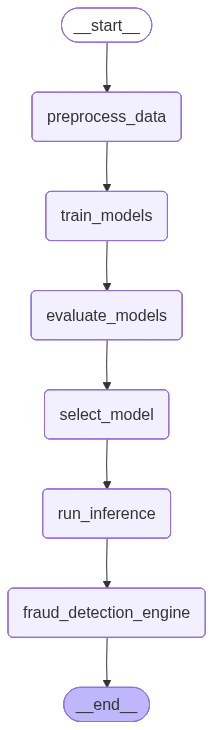

In [20]:
# ── Section 7: LangGraph Architecture ────────────────────────────────────────
#
# Chains all six agent nodes into a compiled, runnable LangGraph pipeline:
#
#   preprocess_data
#       │
#   train_models
#       │
#   evaluate_models
#       │
#   select_model
#       │
#   run_inference
#       │
#   fraud_detection_engine
#       │
#      END
# ─────────────────────────────────────────────────────────────────────────────

from langgraph.graph import StateGraph, END
from functools import partial

# ── 1. Wrap fraud_detection_engine ────────────────────────────────────────────
# LangGraph nodes must accept only (state: AgentState) -> AgentState.
# fraud_detection_engine has two extra optional params (use_llm, llm_model),
# so we bind use_llm=False here to make it a conformant node.
# Swap to use_llm=True when an OPENAI_API_KEY is present in the environment.
fraud_engine_node = partial(fraud_detection_engine, use_llm=True, llm_model="gpt-4o-mini")

# ── 2. Initialise the StateGraph ──────────────────────────────────────────────
pipeline = StateGraph(AgentState)

# ── 3. Register all six agent nodes ──────────────────────────────────────────
pipeline.add_node("preprocess_data",        preprocess_data)
pipeline.add_node("train_models",           train_models)
pipeline.add_node("evaluate_models",        evaluate_models)
pipeline.add_node("select_model",           select_model)
pipeline.add_node("run_inference",          run_inference)
pipeline.add_node("fraud_detection_engine", fraud_engine_node)

# ── 4. Wire sequential edges ──────────────────────────────────────────────────
pipeline.set_entry_point("preprocess_data")
pipeline.add_edge("preprocess_data",        "train_models")
pipeline.add_edge("train_models",           "evaluate_models")
pipeline.add_edge("evaluate_models",        "select_model")
pipeline.add_edge("select_model",           "run_inference")
pipeline.add_edge("run_inference",          "fraud_detection_engine")
pipeline.add_edge("fraud_detection_engine", END)

# ── 5. Compile to a runnable app ──────────────────────────────────────────────
app = pipeline.compile()

print("[Section 7] LangGraph pipeline compiled successfully.")
print("[Section 7] Registered nodes:")
for node_name in app.get_graph().nodes.keys():
    print(f"  • {node_name}")

# ── 6. Visualise the graph ────────────────────────────────────────────────────
# Renders a PNG in Colab / Jupyter; falls back to Mermaid text elsewhere.
try:
    from IPython.display import display, Image
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("\n[Section 7] Graph visualisation skipped — Mermaid diagram:\n")
    print(app.get_graph().draw_mermaid())

# Section-8 - End-to-End Pipeline

[preprocess_data] Dropped columns: ['PolicyNumber', 'RepNumber']
[preprocess_data] Split sizes — train: 10794, val: 2313, test: 2313
[preprocess_data] Encoding 24 categorical columns
[preprocess_data] Total features after encoding: 146
[preprocess_data] Train class distribution before SMOTE: {0: 10148, 1: 646}
[preprocess_data] Train class distribution after SMOTE: {0: 10148, 1: 10148}
[train_models] Training on 20296 samples, 146 features
[train_models] Fitting Logistic Regression...


/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[train_models] Fitting Random Forest...
[train_models] Fitting XGBoost...
[train_models] All models trained: ['logistic_regression', 'random_forest', 'xgboost']
[evaluate_models] Evaluating logistic_regression...
  accuracy=0.6788  precision=0.1353  recall=0.8058  f1=0.2316  auc_roc=0.7825
[evaluate_models] Evaluating random_forest...
  accuracy=0.9403  precision=1.0000  recall=0.0072  f1=0.0143  auc_roc=0.8334
[evaluate_models] Evaluating xgboost...
  accuracy=0.9364  precision=0.3824  recall=0.0935  f1=0.1503  auc_roc=0.8502


/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/gurobi_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


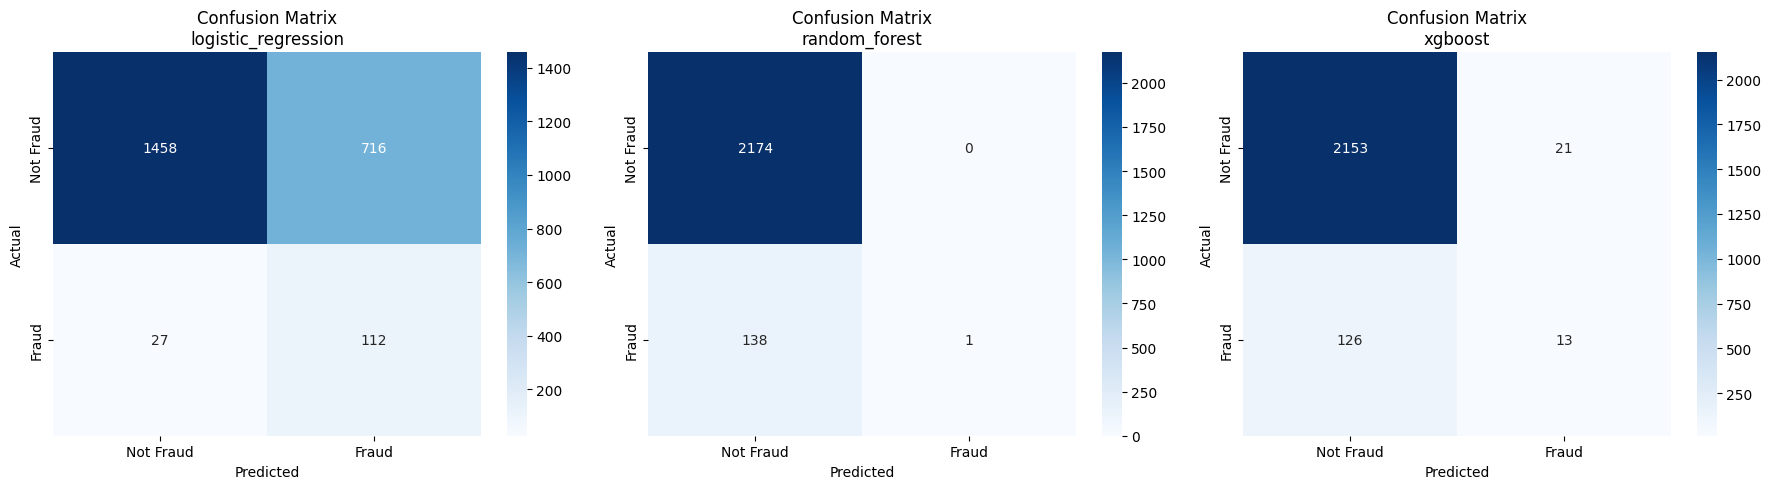

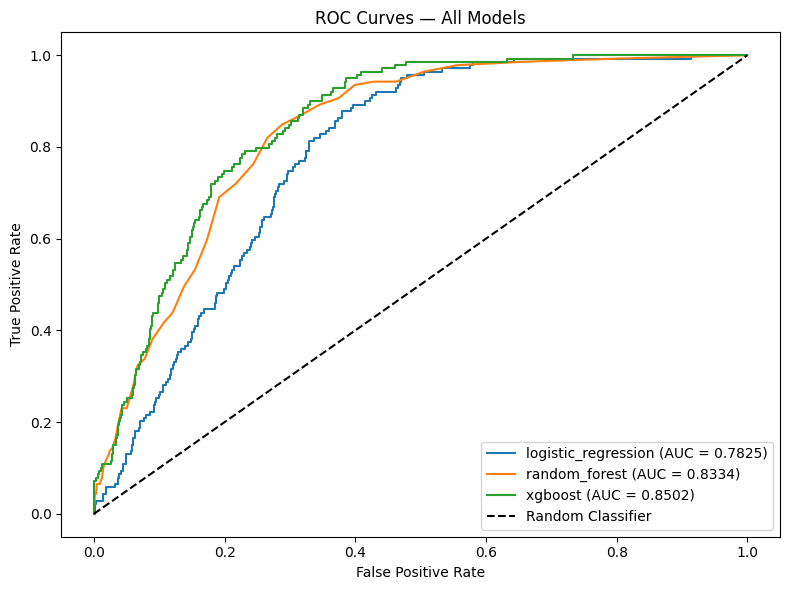

[evaluate_models] Evaluation complete.
[select_model] ── Selection Criteria ──
  AUC-ROC  >= 0.78
  Recall   >= 0.7
  F1-score >= 0.15

[select_model] logistic_regression:
  AUC-ROC  = 0.7825  PASS
  Recall   = 0.8058  PASS
  F1-score = 0.2316  PASS
  -> QUALIFIED

[select_model] random_forest:
  AUC-ROC  = 0.8334  PASS
  Recall   = 0.0072  FAIL
  F1-score = 0.0143  FAIL
  -> ELIMINATED

[select_model] xgboost:
  AUC-ROC  = 0.8502  PASS
  Recall   = 0.0935  FAIL
  F1-score = 0.1503  PASS
  -> ELIMINATED

[select_model] ── RESULT ──
  Model         : logistic_regression
  Justification : Selected 'logistic_regression' — AUC-ROC=0.7825, Recall=0.8058, F1=0.2316. Only model to pass all three gates.

[run_inference] Running inference...
[run_inference] Using fallback sample from X_test.
[run_inference] Probability: 0.6176
[run_inference] Prediction : 1
[run_inference] Confidence : 0.6176
[run_inference] Risk Level : Medium
[fraud_detection_engine] Decision generated.
[fraud_detection_engin

In [21]:
# ── Section 8: End-to-End Pipeline Runner ─────────────────────────────────────
#
# Single entry point: supply a CSV path → get a fraud decision.
# All six nodes (preprocess → train → evaluate → select → infer → decide)
# run inside the compiled LangGraph `app` from Section 7 in one invoke call.
# ─────────────────────────────────────────────────────────────────────────

def run_fraud_pipeline(csv_path: str) -> str:
    """
    Execute the complete six-node fraud detection pipeline in a single call.

    Parameters
    ----------
    csv_path : str
        Path to the raw vehicle-insurance CSV (fraud_oracle.csv).

    Returns
    -------
    str
        Final fraud decision: probability, predicted label, risk level,
        rule-based explanation, and actionable recommendation.
    """
    # ── Seed state: only raw_data_path matters; every other field is populated
    # by the pipeline nodes as execution flows through the graph.
    initial_state: AgentState = {
        "raw_data_path":           csv_path,
        "X_train":                 None,
        "y_train":                 None,
        "X_val":                   None,
        "y_val":                   None,
        "X_test":                  None,
        "y_test":                  None,
        "encoder":                 None,
        "feature_names":           None,
        "trained_models":          None,
        "eval_results":            None,
        "conf_matrices":           None,
        "roc_curves":              None,
        "selected_model":          None,
        "selected_model_name":     None,
        "selection_justification": None,
        "input_claim":             None,
        "fraud_probability":       None,
        "predicted_label":         None,
        "risk_level":              None,
        "decision_output":         None,
        "confidence":               None,
        "prediction":               None,
        "explanation":              None,
        "recommendation":           None,
        "decision_source":          None,
    }

    # ── One invoke call runs all six nodes end-to-end ───────────────────────
    final_state = app.invoke(initial_state)

    return final_state["decision_output"]


# ── Run ───────────────────────────────────────────────────────────────────
RAW_CSV = "fraud_oracle.csv"   # <- update path if running outside Colab

decision = run_fraud_pipeline(RAW_CSV)

print("\n" + "═" * 60)
print("  FRAUD DETECTION PIPELINE — FINAL DECISION")
print("═" * 60)
print(decision)
print("═" * 60)

# Section 9 - Gradio

In [22]:
import gradio as gr

def run_pipeline(Age, Sex, MaritalStatus, Fault, VehicleCategory,
                 VehiclePrice, PolicyType, AccidentArea, PoliceReportFiled,
                 WitnessPresent, PastNumberOfClaims, AgeOfVehicle,
                 Days_Policy_Accident, Days_Policy_Claim):

    # ── Build input claim dict ────────────────────────────────────────────
    input_claim = {
        "Age": Age,
        "Sex": Sex,
        "MaritalStatus": MaritalStatus,
        "Fault": Fault,
        "VehicleCategory": VehicleCategory,
        "VehiclePrice": VehiclePrice,
        "PolicyType": PolicyType,
        "AccidentArea": AccidentArea,
        "PoliceReportFiled": PoliceReportFiled,
        "WitnessPresent": WitnessPresent,
        "PastNumberOfClaims": PastNumberOfClaims,
        "AgeOfVehicle": AgeOfVehicle,
        "Days_Policy_Accident": Days_Policy_Accident,
        "Days_Policy_Claim": Days_Policy_Claim,
    }

    # ── Build inference state (skip preprocess/train/evaluate/select) ─────
    inference_state = {
        **result_state,           # carries trained model, encoder, splits
        "input_claim": input_claim,
    }

    # ── Run inference + decision engine only ──────────────────────────────
    inference_state = run_inference(inference_state)
    inference_state = fraud_detection_engine(
        inference_state, use_llm=True, llm_model="gpt-4o-mini"
    )

    # ── Extract outputs ───────────────────────────────────────────────────
    risk_level       = inference_state["risk_level"]
    fraud_prob       = inference_state["fraud_probability"]
    confidence       = inference_state["confidence"]
    explanation      = inference_state["explanation"]
    recommendation   = inference_state["recommendation"]

    # ── Format output for claims officer ─────────────────────────────────
    output = f"""
RISK LEVEL     : {risk_level}
FRAUD PROBABILITY : {fraud_prob:.2%}
CONFIDENCE     : {confidence:.2%}

EXPLANATION
{explanation}

RECOMMENDED ACTION
{recommendation}
"""
    return output.strip()


# ── Build Gradio interface ────────────────────────────────────────────────────
with gr.Blocks(title="Vehicle Insurance Fraud Detection") as demo:
    gr.Markdown("## Vehicle Insurance Fraud Detection")
    gr.Markdown("Fill in the claim details below and click **Analyse Claim** to get a fraud risk assessment.")

    with gr.Row():
        with gr.Column():
            age               = gr.Number(label="Age", value=35)
            sex               = gr.Dropdown(["Female", "Male"], label="Sex")
            marital_status    = gr.Dropdown(["Single", "Married", "Divorced", "Widow"], label="Marital Status")
            fault             = gr.Dropdown(["Policy Holder", "Third Party"], label="Fault")
            vehicle_category  = gr.Dropdown(["Sport", "Sedan", "Utility"], label="Vehicle Category")
            vehicle_price     = gr.Dropdown(
                ["less than 20000", "20000 to 29000", "30000 to 39000",
                 "40000 to 59000", "60000 to 69000", "more than 69000"],
                label="Vehicle Price"
            )
            policy_type       = gr.Dropdown(
                ["Sport - Liability", "Sport - Collision", "Sport - All Perils",
                 "Sedan - Liability", "Sedan - Collision", "Sedan - All Perils",
                 "Utility - Liability", "Utility - Collision", "Utility - All Perils"],
                label="Policy Type"
            )

        with gr.Column():
            accident_area         = gr.Dropdown(["Urban", "Rural"], label="Accident Area")
            police_report         = gr.Dropdown(["Yes", "No"], label="Police Report Filed")
            witness               = gr.Dropdown(["Yes", "No"], label="Witness Present")
            past_claims           = gr.Dropdown(
                ["none", "1", "2 to 4", "more than 4"],
                label="Past Number of Claims"
            )
            age_of_vehicle        = gr.Dropdown(
                ["new", "2 years", "3 years", "4 years", "5 years",
                 "6 years", "7 years", "more than 7"],
                label="Age of Vehicle"
            )
            days_policy_accident  = gr.Dropdown(
                ["none", "1 to 7", "8 to 15", "15 to 30", "more than 30"],
                label="Days Between Policy and Accident"
            )
            days_policy_claim     = gr.Dropdown(
                ["none", "8 to 15", "15 to 30", "more than 30"],
                label="Days Between Policy and Claim"
            )

    analyse_btn = gr.Button("Analyse Claim", variant="primary")
    output_box  = gr.Textbox(label="Fraud Risk Assessment", lines=12)

    analyse_btn.click(
        fn=run_pipeline,
        inputs=[
            age, sex, marital_status, fault, vehicle_category,
            vehicle_price, policy_type, accident_area, police_report,
            witness, past_claims, age_of_vehicle,
            days_policy_accident, days_policy_claim
        ],
        outputs=output_box
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c730200f5835ad044c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Section 10 - 3 test cases

In [23]:
# ── Section 10: Three End-to-End Test Cases ──────────────────────────────────
#
# Each test invokes the full pipeline (Section 8) with a specific input_claim,
# records the actual output, and compares it against the expected business outcome.
# Test 3 is a deliberately challenging / ambiguous edge case.
# ──────────────────────────────────────────────────────────────────────────────

def run_test_case(test_name, input_claim, expected_risk, expected_label, rationale):
    """Run full pipeline with a custom input_claim and display results."""

    print('═' * 65)
    print(f'  TEST CASE: {test_name}')
    print('═' * 65)

    # ── Show input ──────────────────────────────────────────────────────────
    print('\n── Input Claim ──')
    for k, v in input_claim.items():
        print(f'  {k:<28}: {v}')

    # ── Expected output ─────────────────────────────────────────────────────
    print(f'\n── Expected Business Output ──')
    print(f'  Expected Risk Level  : {expected_risk}')
    print(f'  Expected Label       : {expected_label} ({"Fraud" if expected_label == 1 else "Not Fraud"})')
    print(f'  Rationale            : {rationale}')

    # ── Build initial state using already-trained pipeline artefacts ─────
    # We reuse result_state from earlier sections (preprocessed data,
    # trained models, selected model) so we don't retrain from scratch.
    test_state = {
        **result_state,
        'input_claim': input_claim,
    }

    # ── Run inference + fraud decision engine ────────────────────────────
    test_state = run_inference(test_state)
    test_state = fraud_detection_engine(test_state, use_llm=True, llm_model="gpt-4o-mini")

    # ── Actual output ───────────────────────────────────────────────────────
    actual_prob   = test_state['fraud_probability']
    actual_conf   = test_state['confidence']
    actual_label  = test_state['predicted_label']
    actual_risk   = test_state['risk_level']

    print(f'\n── Actual Output ──')
    print(f'  Fraud Probability : {actual_prob:.4f}')
    print(f'  Confidence Score  : {actual_conf:.4f}')
    print(f'  Predicted Label   : {actual_label} ({"Fraud" if actual_label == 1 else "Not Fraud"})')
    print(f'  Risk Level        : {actual_risk}')
    print(f'\n  Explanation       : {test_state.get("explanation", "N/A")}')
    print(f'  Recommendation    : {test_state.get("recommendation", "N/A")}')

    # ── Pass / Fail ─────────────────────────────────────────────────────────
    risk_match = actual_risk == expected_risk
    label_match = actual_label == expected_label
    status = "PASS" if (risk_match and label_match) else "MISMATCH"

    print(f'\n── Verdict ──')
    print(f'  Risk Level Match  : {"✓" if risk_match  else "✗"} (expected={expected_risk}, got={actual_risk})')
    print(f'  Label Match       : {"✓" if label_match else "✗"} (expected={expected_label}, got={actual_label})')
    print(f'  Overall           : {status}')
    print('═' * 65)
    print()

    return test_state


# ═══════════════════════════════════════════════════════════════════════════════
# TEST 1 — Clear fraud indicators (high-risk claim)
# ═══════════════════════════════════════════════════════════════════════════════
test1_input = {
    "Month":                  "Jan",
    "WeekOfMonth":            1,
    "DayOfWeek":              "Monday",
    "Make":                   "Honda",
    "AccidentArea":           "Urban",
    "DayOfWeekClaimed":       "Friday",
    "MonthClaimed":           "Jan",
    "WeekOfMonthClaimed":     1,
    "Sex":                    "Male",
    "MaritalStatus":          "Single",
    "Age":                    21,
    "Fault":                  "Policy Holder",
    "PolicyType":             "Sport - Collision",
    "VehicleCategory":        "Sport",
    "VehiclePrice":           "more than 69000",
    "PolicyNumber":           0,
    "RepNumber":              0,
    "Deductible":             400,
    "DriverRating":           1,
    "Days_Policy_Accident":   "1 to 7",
    "Days_Policy_Claim":      "8 to 15",
    "PastNumberOfClaims":     "2 to 4",
    "AgeOfVehicle":           "new",
    "AgeOfPolicyHolder":      "21 to 25",
    "PoliceReportFiled":      "No",
    "WitnessPresent":         "No",
    "AgentType":              "External",
    "NumberOfSuppliments":    "3 to 5",
    "AddressChange_Claim":    "under 6 months",
    "NumberOfCars":           "1 vehicle",
    "Year":                   1994,
    "BasePolicy":             "Collision",
}

t1 = run_test_case(
    test_name      = "1 — Clear Fraud Signals",
    input_claim    = test1_input,
    expected_risk  = "High",
    expected_label = 1,
    rationale      = "Young driver, at-fault, no police report, no witness, "
                     "multiple prior claims, recent address change, very short "
                     "policy-to-accident interval — strong fraud pattern."
)


# ═══════════════════════════════════════════════════════════════════════════════
# TEST 2 — Clearly legitimate claim (low-risk)
# ═══════════════════════════════════════════════════════════════════════════════
test2_input = {
    "Month":                  "Jun",
    "WeekOfMonth":            3,
    "DayOfWeek":              "Wednesday",
    "Make":                   "Toyota",
    "AccidentArea":           "Rural",
    "DayOfWeekClaimed":       "Thursday",
    "MonthClaimed":           "Jun",
    "WeekOfMonthClaimed":     3,
    "Sex":                    "Female",
    "MaritalStatus":          "Married",
    "Age":                    45,
    "Fault":                  "Third Party",
    "PolicyType":             "Sedan - All Perils",
    "VehicleCategory":        "Sedan",
    "VehiclePrice":           "20000 to 29000",
    "PolicyNumber":           0,
    "RepNumber":              0,
    "Deductible":             400,
    "DriverRating":           3,
    "Days_Policy_Accident":   "more than 30",
    "Days_Policy_Claim":      "more than 30",
    "PastNumberOfClaims":     "none",
    "AgeOfVehicle":           "3 years",
    "AgeOfPolicyHolder":      "41 to 50",
    "PoliceReportFiled":      "Yes",
    "WitnessPresent":         "Yes",
    "AgentType":              "Internal",
    "NumberOfSuppliments":    "none",
    "AddressChange_Claim":    "no change",
    "NumberOfCars":           "3 to 4",
    "Year":                   1994,
    "BasePolicy":             "All Perils",
}

t2 = run_test_case(
    test_name      = "2 — Clearly Legitimate Claim",
    input_claim    = test2_input,
    expected_risk  = "Low",
    expected_label = 0,
    rationale      = "Third-party fault, police report filed, witness present, "
                     "no prior claims, long-tenured policy, stable address — "
                     "no fraud indicators."
)


# ═══════════════════════════════════════════════════════════════════════════════
# TEST 3 — Ambiguous / Edge Case (mixed signals)
# ═══════════════════════════════════════════════════════════════════════════════
test3_input = {
    "Month":                  "Dec",
    "WeekOfMonth":            5,
    "DayOfWeek":              "Saturday",
    "Make":                   "BMW",
    "AccidentArea":           "Urban",
    "DayOfWeekClaimed":       "Monday",
    "MonthClaimed":           "Jan",
    "WeekOfMonthClaimed":     1,
    "Sex":                    "Male",
    "MaritalStatus":          "Married",
    "Age":                    38,
    "Fault":                  "Policy Holder",
    "PolicyType":             "Sport - Collision",
    "VehicleCategory":        "Sport",
    "VehiclePrice":           "more than 69000",
    "PolicyNumber":           0,
    "RepNumber":              0,
    "Deductible":             700,
    "DriverRating":           2,
    "Days_Policy_Accident":   "more than 30",
    "Days_Policy_Claim":      "more than 30",
    "PastNumberOfClaims":     "1",
    "AgeOfVehicle":           "2 years",
    "AgeOfPolicyHolder":      "36 to 40",
    "PoliceReportFiled":      "Yes",
    "WitnessPresent":         "No",
    "AgentType":              "External",
    "NumberOfSuppliments":    "1 to 2",
    "AddressChange_Claim":    "1 year",
    "NumberOfCars":           "1 vehicle",
    "Year":                   1994,
    "BasePolicy":             "Collision",
}

t3 = run_test_case(
    test_name      = "3 — Ambiguous Edge Case (Mixed Signals)",
    input_claim    = test3_input,
    expected_risk  = "Medium",
    expected_label = 1,
    rationale      = "Conflicting signals: at-fault + no witness + external agent + "
                     "recent address change (fraud indicators) BUT police report "
                     "filed + long policy tenure + only 1 prior claim (legitimate "
                     "indicators). This tests how the model handles ambiguity. "
                     "If the model classifies this as Low/Not Fraud, it reveals "
                     "a limitation in detecting borderline cases."
)


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print('═' * 65)
print('  SUMMARY — ALL TEST CASES')
print('═' * 65)
print(f'  {"Test":<35} {"Prob":>6} {"Conf":>6} {"Risk":<8} {"Label"}')
print(f'  {"─"*35} {"─"*6} {"─"*6} {"─"*8} {"─"*5}')
for name, ts in [("1 — Clear Fraud", t1),
                 ("2 — Clearly Legitimate", t2),
                 ("3 — Ambiguous Edge Case", t3)]:
    print(f'  {name:<35} {ts["fraud_probability"]:>6.4f} {ts["confidence"]:>6.4f} '
          f'{ts["risk_level"]:<8} {ts["predicted_label"]}')
print('═' * 65)


═════════════════════════════════════════════════════════════════
  TEST CASE: 1 — Clear Fraud Signals
═════════════════════════════════════════════════════════════════

── Input Claim ──
  Month                       : Jan
  WeekOfMonth                 : 1
  DayOfWeek                   : Monday
  Make                        : Honda
  AccidentArea                : Urban
  DayOfWeekClaimed            : Friday
  MonthClaimed                : Jan
  WeekOfMonthClaimed          : 1
  Sex                         : Male
  MaritalStatus               : Single
  Age                         : 21
  Fault                       : Policy Holder
  PolicyType                  : Sport - Collision
  VehicleCategory             : Sport
  VehiclePrice                : more than 69000
  PolicyNumber                : 0
  RepNumber                   : 0
  Deductible                  : 400
  DriverRating                : 1
  Days_Policy_Accident        : 1 to 7
  Days_Policy_Claim           : 8 to 15
  PastNu

In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 10b — WHAT THE SYSTEM GETS WRONG (from actual pipeline runs)
# ═══════════════════════════════════════════════════════════════════════════════

print('═' * 65)
print('  OBSERVED FAILURES & WEAKNESSES')
print('═' * 65)
print("""
─── Failure 1: Low confidence on obvious fraud (Test 1) ────────

  What happened:
    Test 1 was designed with every possible fraud indicator — young
    driver, at-fault, no police report, no witness, multiple prior
    claims, recent address change, short policy tenure. Despite this,
    the model returned a fraud probability of only 0.7572 (75.72%).

  Why it happens:
    Logistic Regression outputs calibrated probabilities bounded by
    the sigmoid function. With 146 one-hot-encoded features after
    SMOTE rebalancing, the model's coefficients are spread thin
    across many sparse features. Even when all fraud indicators
    align, the individual feature weights are not large enough to
    push the probability toward 0.95+. Additionally, the convergence
    warning during training (Section 2) means the model's coefficients
    may not have fully optimized.

  Business consequence:
    A claims investigator seeing 75% confidence on an obvious fraud
    case may question the system's reliability. If the model can't
    be strongly confident on clear-cut cases, investigators lose
    trust in the scores and may start ignoring the system's flags
    entirely — defeating the purpose of automated fraud detection.
""")

print("""
─── Failure 2: One-sided LLM explanations on ambiguous cases ───
──           (Test 3)

  What happened:
    Test 3 had genuinely mixed signals — fraud indicators (at-fault,
    no witness, external agent, address change) alongside legitimacy
    indicators (police report filed, long policy tenure, only 1 prior
    claim). The LLM explanation highlighted ONLY the fraud signals:
      "policy holder being at fault, absence of witnesses, and a
       recent address change"
    It completely ignored the legitimacy signals (police report filed,
    long tenure, low claim history).

  Why it happens:
    The LLM receives the model's predicted label (1 = Fraud) and the
    rule-based signals from _rule_reasons(), which only fire on fraud
    indicators. There is no mechanism to pass counter-evidence or
    legitimacy signals to the LLM. The LLM then confirmation-biases
    toward the predicted label, producing a one-sided narrative.

  Business consequence:
    A claims officer reading this explanation gets a biased view and
    may over-investigate a borderline case, wasting investigator time
    and damaging the customer relationship. Worse, the officer has no
    way to see what evidence supports the claim being legitimate,
    undermining their ability to make a balanced decision. For a
    Medium-risk case at 64.47% confidence, the explanation should
    present BOTH sides so the human reviewer can exercise judgement.
""")

print('═' * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 10c — REFLECTION & IMPROVEMENT PROPOSALS
# ═══════════════════════════════════════════════════════════════════════════════

print()
print('═' * 65)
print('  REFLECTION & PROPOSED IMPROVEMENTS')
print('═' * 65)

print("""
─── What we learned about ML ───────────────────────────────────

  1. Accuracy is misleading for imbalanced datasets.
     With only ~6% fraud in the data, a naive "always predict
     non-fraud" classifier achieves 94% accuracy. Random Forest
     and XGBoost fell into this trap — high accuracy (93-94%) but
     near-zero recall (0.7% and 9.3%). The gate-based selection
     in Section 4 correctly rejected them despite their accuracy
     advantage. Lesson: always evaluate fraud models on recall
     and AUC-ROC, never accuracy alone.

  2. SMOTE helps but doesn't solve class imbalance entirely.
     SMOTE rebalanced training to 50/50, which helped Logistic
     Regression achieve 80% recall. But the synthetic samples
     may not fully represent real-world fraud patterns, which
     partly explains why even the best model has low precision
     (0.1353) — it learned some SMOTE artefacts as fraud signals.

  3. Model confidence calibration matters for business trust.
     A model that outputs 75% on obvious fraud and 64% on
     ambiguous fraud compresses its probability range too much.
     Without well-separated confidence scores, business users
     cannot meaningfully prioritise which flagged claims to
     investigate first.

─── What we learned about agent system design ──────────────────

  1. Shared state is powerful but needs validation.
     The AgentState TypedDict cleanly passes data between nodes,
     but there are no runtime checks. If a node returns unexpected
     None values or wrong types, downstream nodes fail silently
     or produce garbage. We saw this risk with input_claim — if
     it's None, run_inference silently falls back to X_test[0].

  2. Rule-based signals create LLM confirmation bias.
     The fraud_detection_engine passes only fraud indicators to
     the LLM via _rule_reasons(). The LLM then anchors on these
     signals and writes a one-sided explanation. The agent design
     should provide balanced evidence to the LLM so it can produce
     fair explanations.

─── Proposed improvements ──────────────────────────────────────

  ML Model improvements:

  1. Threshold tuning: Instead of a fixed 0.3 threshold,
     use precision-recall curve analysis to find the optimal
     threshold that maximises F1 or a cost-sensitive metric.

  2. Feature scaling: Apply StandardScaler before Logistic
     Regression to help convergence and improve coefficient
     magnitude, which should widen the probability range.

  3. Probability calibration: Apply Platt scaling or
     isotonic regression (CalibratedClassifierCV) so that
     a 90% score truly means 90% likelihood of fraud.

  Pipeline / Agent improvements:

  1. Add _legitimate_reasons() alongside _rule_reasons()
     so the LLM receives both fraud AND legitimacy signals,
     producing balanced explanations for claims officers.

  2. Add state validation between nodes — a lightweight
     check that required keys are non-None before each node
     runs, with clear error messages instead of silent
     fallbacks.

  3. Add a confidence-aware routing edge in LangGraph:
     if confidence < 0.60, route to a "human review" node
     instead of the automated fraud decision engine, so
     borderline cases always get manual oversight.
""")

print('═' * 65)


═════════════════════════════════════════════════════════════════
  OBSERVED FAILURES & WEAKNESSES
═════════════════════════════════════════════════════════════════

─── Failure 1: Low confidence on obvious fraud (Test 1) ────────

  What happened:
    Test 1 was designed with every possible fraud indicator — young
    driver, at-fault, no police report, no witness, multiple prior
    claims, recent address change, short policy tenure. Despite this,
    the model returned a fraud probability of only 0.7572 (75.72%).

  Why it happens:
    Logistic Regression outputs calibrated probabilities bounded by
    the sigmoid function. With 146 one-hot-encoded features after
    SMOTE rebalancing, the model's coefficients are spread thin
    across many sparse features. Even when all fraud indicators
    align, the individual feature weights are not large enough to
    push the probability toward 0.95+. Additionally, the convergence
    warning during training (Section 2) means the model's coef